# glmmTMB: Extended GLMMs

## Overview
`glmmTMB` (Brooks et al. 2017) fits generalised linear mixed models using Template Model Builder (TMB), enabling distributions and model structures not available in `lme4`:

| Feature | lme4 | glmmTMB |
|---|---|---|
| Gaussian, Poisson, binomial | ✓ | ✓ |
| Negative binomial (NB1, NB2) | via MASS::glmer.nb | ✓ |
| Zero-inflated models | via pscl (no RE) | ✓ (with RE) |
| Zero-truncated models | ✗ | ✓ |
| Beta (proportions) | ✗ | ✓ |
| Tweedie | ✗ | ✓ |
| Beta-binomial | ✗ | ✓ |
| Truncated Poisson/NB | ✗ | ✓ |
| Compound symmetric, AR1, spatial | limited | ✓ |

**Primary use case in ecology:** overdispersed or zero-inflated count data with random effects — the combination that neither `lme4` alone nor `pscl` alone handles.

---

### Note on Installing `tweedie`

The `tweedie` package can be installed manually from a `.tar.gz` file if it is not available via CRAN for your R version. Follow these steps:

1. Download the `.tar.gz` file from the [CRAN tweedie page](https://cran.r-project.org/web/packages/tweedie/index.html).
2. Use the following R command to install it:
   ```R
   install.packages("path_to_downloaded_file.tar.gz", repos = NULL, type = "source")
   ```
   Replace `path_to_downloaded_file.tar.gz` with the actual path to the downloaded file.

This approach ensures compatibility with your R environment.

In [7]:
library(tidyverse); library(glmmTMB); library(DHARMa); library(bbmle); library(tweedie)
set.seed(66)
# Seabird chick survival: count data with zero-inflation and random site effects
# Response: number of fledglings per nest (0 to ~6)
# Predictors: year (fixed), food_index (fixed), site (random)
n_sites <- 12; n_nests <- 15
dat <- expand.grid(
  site  = factor(1:n_sites),
  nest  = 1:n_nests
)
site_re <- rep(rnorm(n_sites, 0, 0.5), each=n_nests)
dat$food_index <- runif(nrow(dat), -1, 1)
dat$year       <- factor(rep(sample(c("2021","2022","2023"), nrow(dat), replace=TRUE)))
# True model: NB with zero-inflation; more food → more fledglings
mu <- exp(0.8 + 0.6*dat$food_index + site_re)
# Zero-inflation: some nests fail completely (predation)
zi_prob <- 0.2
dat$fledglings <- ifelse(runif(nrow(dat)) < zi_prob, 0,
                         rnbinom(nrow(dat), mu=mu, size=2))
cat("Dataset: n =", nrow(dat), "nests, zero proportion =",
    round(mean(dat$fledglings==0),2), "\n")
print(table(dat$fledglings))

Dataset: n = 180 nests, zero proportion = 0.32 

 0  1  2  3  4  5  6  7  8  9 10 11 12 
58 33 28 20 10  8  7  6  2  3  1  3  1 


---
## Model fitting: comparing family choices

In [8]:
# Fit competing models: Poisson, NB, zero-inflated NB
m_pois <- glmmTMB(fledglings ~ food_index + year + (1|site),
                  data=dat, family=poisson)
m_nb   <- glmmTMB(fledglings ~ food_index + year + (1|site),
                  data=dat, family=nbinom2)  # NB2: var = mu + mu²/k
m_zinb <- glmmTMB(fledglings ~ food_index + year + (1|site),
                  ziformula = ~1,             # ZI intercept-only
                  data=dat, family=nbinom2)
m_zinb_zi_cov <- glmmTMB(
  fledglings ~ food_index + year + (1|site),
  ziformula = ~ food_index,    # ZI probability varies with food
  data=dat, family=nbinom2)

cat("AIC comparison:\n")
print(AICtab(m_pois, m_nb, m_zinb, m_zinb_zi_cov, weights=TRUE))

AIC comparison:
              dAIC  df weight
m_nb            0.0 6  0.46  
m_zinb          0.6 7  0.35  
m_zinb_zi_cov   1.8 8  0.19  
m_pois        125.7 5  <0.001


DHARMa diagnostics for ZINB model:


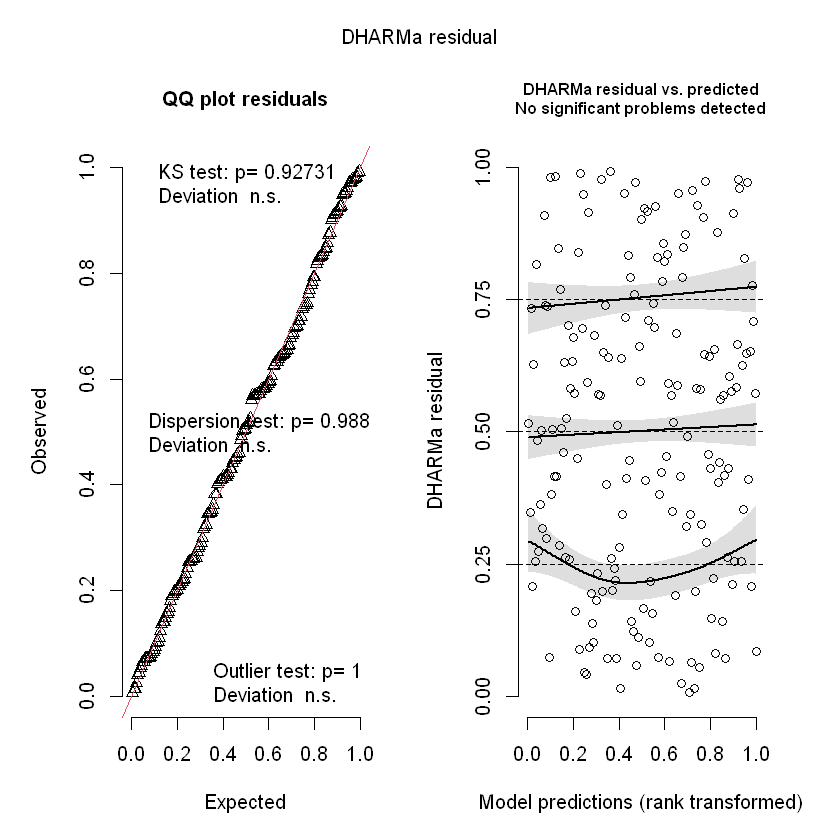


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 1.004, p-value = 1
alternative hypothesis: two.sided


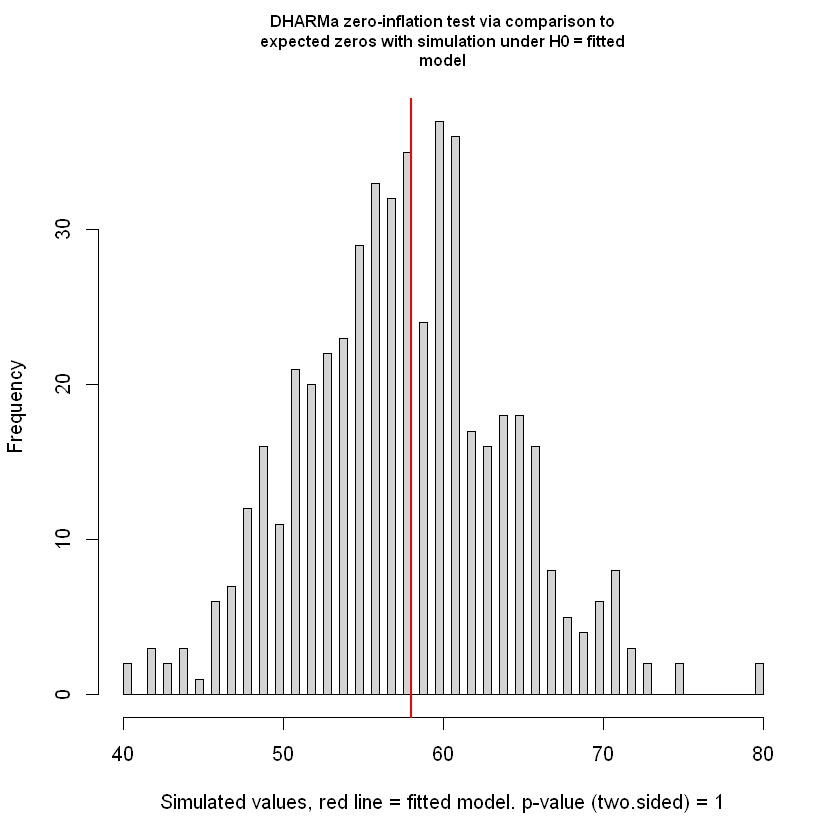


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.97297, p-value = 0.988
alternative hypothesis: two.sided



Model summary (best model):
 Family: nbinom2  ( log )
Formula:          fledglings ~ food_index + year + (1 | site)
Zero inflation:              ~1
Data: dat

      AIC       BIC    logLik -2*log(L)  df.resid 
    730.0     752.3    -358.0     716.0       173 

Random effects:

Conditional model:
 Groups Name        Variance  Std.Dev. 
 site   (Intercept) 5.517e-09 7.428e-05
Number of obs: 180, groups:  site, 12

Dispersion parameter for nbinom2 family (): 1.61 

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.9474     0.1764   5.371 7.82e-08 ***
food_index    0.1124     0.1543   0.728   0.4663    
year2022     -0.3558     0.2151  -1.654   0.0981 .  
year2023      0.2822     0.2023   1.395   0.1631    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Zero-inflation model:
            Estimate Std. Error z value Pr(>|z|)  
(Intercept)  -1.9435     0.7549  -2.574     0.01 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.

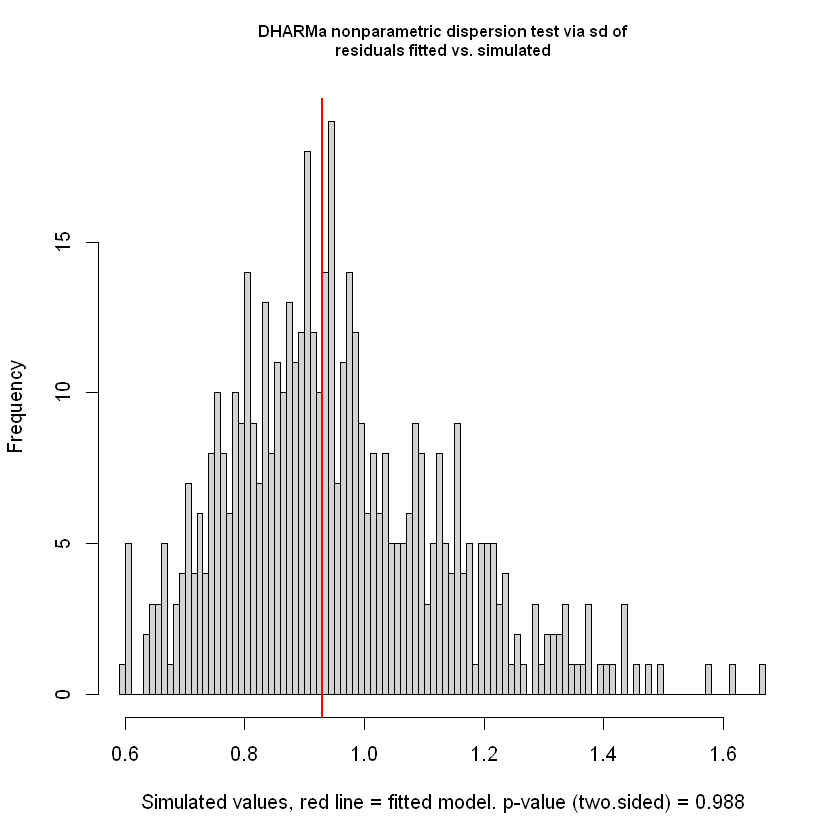

In [9]:
# DHARMa diagnostics on best model
cat("DHARMa diagnostics for ZINB model:\n")
sim_zinb <- simulateResiduals(m_zinb, n=500)
plot(sim_zinb)
testZeroInflation(sim_zinb)
testDispersion(sim_zinb)

cat("\nModel summary (best model):\n")
print(summary(m_zinb))
cat("\nZero-inflation probability (intercept on logit scale):\n")
zi_logit <- fixef(m_zinb)$zi["(Intercept)"]
cat("  logit(ZI):", round(zi_logit,3),
    "→ P(structural zero) =", round(plogis(zi_logit),3), "\n")

In [11]:
# Other useful glmmTMB families
cat("Other glmmTMB families:\n\n")

# Beta regression for proportions (0,1)
dat$prop <- rbeta(nrow(dat), 2, 3)  # simulate proportion response
m_beta <- glmmTMB(prop ~ food_index + (1|site),
                  data=dat, family=beta_family(link="logit"))
cat("Beta family (proportions in (0,1)):\n"); print(summary(m_beta)$coefficients$cond)

# Tweedie for continuous non-negative data with exact zeros
dat$biomass <- tweedie::rtweedie(nrow(dat), mu=5, phi=2, power=1.5)
m_tw <- glmmTMB(biomass ~ food_index + (1|site),
                data=dat, family=tweedie(link="log"))
cat("\nTweedie family (continuous ≥ 0 with point mass at zero):\n")
print(summary(m_tw)$coefficients$cond)

cat("\nglmmTMB formula structure:\n")
cat("  count_component:  fledglings ~ fixed + (random)\n")
cat("  ziformula:        ~ ZI predictors (1 = intercept-only ZI)\n")
cat("  dispformula:      ~ dispersion predictors (allows heterogeneous dispersion)\n")

Other glmmTMB families:



Beta family (proportions in (0,1)):
                 Estimate Std. Error      z value     Pr(>|z|)
(Intercept) -0.3222127993  0.0606963 -5.308607062 1.104662e-07
food_index   0.0002119893  0.1074061  0.001973717 9.984252e-01
attr(,"ddf")
[1] "asymptotic"

Tweedie family (continuous ≥ 0 with point mass at zero):
              Estimate Std. Error    z value     Pr(>|z|)
(Intercept) 1.51861233 0.07712949 19.6891281 2.672502e-86
food_index  0.03803532 0.13217514  0.2877646 7.735270e-01
attr(,"ddf")
[1] "asymptotic"

glmmTMB formula structure:
  count_component:  fledglings ~ fixed + (random)
  ziformula:        ~ ZI predictors (1 = intercept-only ZI)
  dispformula:      ~ dispersion predictors (allows heterogeneous dispersion)


---
## Common Pitfalls

**1. Using glmmTMB with nbinom1 vs nbinom2 without thinking**
glmmTMB offers two NB parameterisations: NB1 (variance = μ·φ, linear mean-variance) and NB2 (variance = μ + μ²/k, quadratic). NB2 is most common in ecology. Try both and compare with AIC — the wrong parameterisation can produce poor fit.

**2. Fitting zero-inflated models to data that are simply overdispersed**
Zero-inflation adds a separate process generating structural zeros. If zeros arise from the same Poisson/NB process (sampling zeros), a ZI model over-parameterises the data. Always compare NB vs ZINB with AIC and check DHARMa zero-inflation test before concluding ZI is needed.

**3. Specifying complex ziformula when data do not support it**
The zero-inflation submodel is fitted to the same data — having many ZI predictors on a small dataset leads to convergence problems and inflated uncertainty. Start with `ziformula = ~1` (intercept-only ZI) before adding covariates to the ZI component.

**4. Ignoring convergence warnings**
glmmTMB convergence warnings are more informative than lme4's but still easy to overlook. Check `m$fit$convergence` (0 = converged) and inspect the Hessian. Common causes: poorly scaled predictors, too-complex random effects, boundary estimates of variance components.

**5. Not using DHARMa diagnostics after fitting**
glmmTMB provides great flexibility but residual diagnostics are not automatic. Always run `simulateResiduals()` + `plot()` + `testDispersion()` + `testZeroInflation()` to verify the chosen family fits the data.

**6. Forgetting that Beta regression requires strictly (0,1) responses**
The beta family in glmmTMB requires proportions strictly between 0 and 1. Values of exactly 0 or 1 cause errors. Use a small transformation `(y*(n-1) + 0.5)/n` (Smithson & Verkuilen 2006) or switch to a zero-one inflated beta model (`family=ordbeta` or `family=beta_family` with manual handling).


---
*r_methods_library - Samantha McGarrigle*